<a href="https://colab.research.google.com/github/Kenny625819/Applied-Data-Science/blob/main/MRI_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
ESCC (Bilsky scale) Inter-Rater Agreement and Consensus Label Generation
[177-case version]

This script performs the following steps:

1. Load ESCC ratings from an Excel file (three raters per case).
2. Compute overall inter-rater agreement using Fleiss' kappa.
3. Compute pairwise Cohen's kappa (unweighted and quadratic-weighted)
   for each rater pair.
4. Generate a consensus ESCC label for each case:
   - If at least two raters agree, the majority label is used.
   - If all three raters disagree, the median label is chosen based on
     the ordinal Bilsky scale.
5. Save the original ratings and the consensus label to a new Excel file.

Expected input format
---------------------
The input Excel file must contain the following columns:

    ESCC_1  : ESCC label from rater 1 (e.g., "1a", "1b", "1c", "2", "3")
    ESCC_2  : ESCC label from rater 2
    ESCC_3  : ESCC label from rater 3

The Bilsky/ESCC labels are treated as an ordinal scale with the following order:
    1a < 1b < 1c < 2 < 3
"""

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import cohen_kappa_score


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
INPUT_EXCEL = "ESCC_3_177.xlsx"
OUTPUT_EXCEL = "ESCC_3_with_consensus_177.xlsx"

# Bilsky/ESCC ordinal scale
ORDERED_LABELS = ["1a", "1b", "1c", "2", "3"]

LABEL_TO_IDX = {lab: i for i, lab in enumerate(ORDERED_LABELS)}
IDX_TO_LABEL = {i: lab for lab, i in LABEL_TO_IDX.items()}


# ---------------------------------------------------------------------
# Fleiss' kappa
# ---------------------------------------------------------------------
def fleiss_kappa(M: np.ndarray):
    """
    Compute Fleiss' kappa for multiple raters.

    Parameters
    ----------
    M : np.ndarray of shape (N, k)
        M[i, j] is the number of raters who assigned category j to case i.

    Returns
    -------
    kappa : float
        Fleiss' kappa.
    P_bar : float
        Mean observed agreement.
    P_e : float
        Expected agreement by chance.
    """
    N, k = M.shape
    n = M.sum(axis=1)[0]  # number of raters per case (assumed constant)

    p_j = M.sum(axis=0) / (N * n)
    P_i = ((M * (M - 1)).sum(axis=1)) / (n * (n - 1))

    P_bar = P_i.mean()
    P_e = (p_j ** 2).sum()

    kappa = (P_bar - P_e) / (1 - P_e)
    return kappa, P_bar, P_e


# ---------------------------------------------------------------------
# Quadratic-weighted Cohen's kappa
# ---------------------------------------------------------------------
def quadratic_weighted_kappa(a, b, labels_order):
    """
    Compute quadratic-weighted Cohen's kappa between two raters.
    """
    lab_to_i = {lab: i for i, lab in enumerate(labels_order)}
    a_idx = np.array([lab_to_i[str(x).strip()] for x in a])
    b_idx = np.array([lab_to_i[str(x).strip()] for x in b])
    n_cat = len(labels_order)

    # Weight matrix
    w = np.zeros((n_cat, n_cat))
    for i in range(n_cat):
        for j in range(n_cat):
            w[i, j] = ((i - j) ** 2) / ((n_cat - 1) ** 2)

    # Observed matrix
    O = np.zeros((n_cat, n_cat))
    for x, y in zip(a_idx, b_idx):
        O[x, y] += 1
    O = O / O.sum()

    # Expected matrix
    a_hist = np.bincount(a_idx, minlength=n_cat)
    b_hist = np.bincount(b_idx, minlength=n_cat)
    E = np.outer(a_hist, b_hist)
    E = E / E.sum()

    num = (w * O).sum()
    den = (w * E).sum()
    return 1.0 - num / den


# ---------------------------------------------------------------------
# Consensus label generation
# ---------------------------------------------------------------------
def consensus_row(row, raters, label_to_idx, idx_to_label):
    """
    Generate a consensus ESCC label for a single case.

    Rules:
    - If at least two raters agree, return the majority label.
    - If all three raters disagree, return the median label on the
      ordinal Bilsky scale (1a < 1b < 1c < 2 < 3).
    """
    vals = [str(row[x]).strip() for x in raters]
    counts = Counter(vals)
    most_common_label, freq = counts.most_common(1)[0]

    if freq >= 2:
        return most_common_label

    idxs = sorted(label_to_idx[v] for v in vals)
    median_idx = idxs[1]
    return idx_to_label[median_idx]


# ---------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------
def main():
    print(f"Loading input file: {INPUT_EXCEL}")
    df = pd.read_excel(INPUT_EXCEL)
    print("Input columns:", list(df.columns))
    print(f"Number of cases: {len(df)}")

    raters = ["ESCC_1", "ESCC_2", "ESCC_3"]

    # Check required columns
    missing_cols = [c for c in raters if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Standardize labels as strings
    for c in raters:
        df[c] = df[c].astype(str).str.strip()

    # Build N x k matrix for Fleiss' kappa
    N = len(df)
    k = len(ORDERED_LABELS)
    M = np.zeros((N, k), dtype=int)

    for i, row in df[raters].iterrows():
        for val in row:
            if pd.isna(val):
                continue
            if val not in LABEL_TO_IDX:
                raise ValueError(f"Unexpected ESCC label found: {val}")
            M[i, LABEL_TO_IDX[val]] += 1

    # Fleiss' kappa
    fleiss_k, P_bar, P_e = fleiss_kappa(M)
    print("\n=== Fleiss' kappa ===")
    print(f"Fleiss' kappa: {fleiss_k:.3f}")
    print(f"P_bar (mean agreement): {P_bar:.3f}")
    print(f"P_e (chance agreement): {P_e:.3f}")

    # Pairwise Cohen's kappa
    print("\n=== Pairwise Cohen's kappa ===")
    pairs = [("ESCC_1", "ESCC_2"), ("ESCC_1", "ESCC_3"), ("ESCC_2", "ESCC_3")]

    for c1, c2 in pairs:
        a = df[c1].values
        b = df[c2].values

        k_unw = cohen_kappa_score(a, b)
        k_w = quadratic_weighted_kappa(a, b, ORDERED_LABELS)

        print(f"{c1} vs {c2}: Unweighted = {k_unw:.3f}, Quadratic-weighted = {k_w:.3f}")

    # Consensus labels
    df["ESCC_consensus"] = df.apply(
        consensus_row,
        axis=1,
        args=(raters, LABEL_TO_IDX, IDX_TO_LABEL),
    )

    print("\n=== Consensus ESCC distribution ===")
    print(df["ESCC_consensus"].value_counts().sort_index())

    full_disagree = (
        (df["ESCC_1"] != df["ESCC_2"]) &
        (df["ESCC_1"] != df["ESCC_3"]) &
        (df["ESCC_2"] != df["ESCC_3"])
    ).sum()

    print(f"\nNumber of full-disagreement cases: {full_disagree}")

    # Save output
    df.to_excel(OUTPUT_EXCEL, index=False)
    print(f"\nSaved consensus results to: {OUTPUT_EXCEL}")


if __name__ == "__main__":
    main()


Loading input file: ESCC_3_177.xlsx
Input columns: ['filename', 'ESCC_1', 'ESCC_2', 'ESCC_3']
Number of cases: 177

=== Fleiss' kappa ===
Fleiss' kappa: 0.579
P_bar (mean agreement): 0.750
P_e (chance agreement): 0.405

=== Pairwise Cohen's kappa ===
ESCC_1 vs ESCC_2: Unweighted = 0.684, Quadratic-weighted = 0.887
ESCC_1 vs ESCC_3: Unweighted = 0.510, Quadratic-weighted = 0.787
ESCC_2 vs ESCC_3: Unweighted = 0.550, Quadratic-weighted = 0.804

=== Consensus ESCC distribution ===
ESCC_consensus
1b     20
1c      8
2      49
3     100
Name: count, dtype: int64

Number of full-disagreement cases: 5

Saved consensus results to: ESCC_3_with_consensus_177.xlsx


In [4]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Dataset Construction for CNN-based ESCC Classification
[177-case version]

This script performs the following steps:

1. Unzips the MRI image archive if needed.
2. Loads consensus ESCC labels from Excel.
3. Scans the image directory and maps numeric IDs to real image filenames.
4. Matches each case in the Excel file to its image.
5. Generates dataset_177.csv for CNN training.

Input:
    - ESCC_3_with_consensus_177.xlsx
    - images177.zip (or extracted folder images177/)

Output:
    - dataset_177.csv

Required Excel columns:
    - filename         : numeric image ID
    - ESCC_consensus   : consensus ESCC label
"""

import os
import zipfile
import pandas as pd

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
ZIP_FILE = "/mnt/data/images177.zip"
IMAGE_DIR = "/mnt/data/images177"
EXCEL_PATH = "/mnt/data/ESCC_3_with_consensus_177.xlsx"
OUTPUT_CSV = "/mnt/data/dataset_177.csv"


def unzip_if_needed(zip_file, image_dir):
    """
    Unzip image archive if the extracted folder does not exist.
    """
    if os.path.exists(image_dir):
        print(f"Image directory already exists: {image_dir}")
        return

    if not os.path.exists(zip_file):
        raise FileNotFoundError(f"ZIP file not found: {zip_file}")

    print(f"Unzipping: {zip_file}")
    with zipfile.ZipFile(zip_file, "r") as zf:
        zf.extractall("/mnt/data")
    print("Unzip completed.")


def build_file_map(image_dir):
    """
    Build mapping from numeric file stem to actual filename.

    Example:
        '12.png' -> file_map['12'] = '12.png'
    """
    img_files = os.listdir(image_dir)
    file_map = {}

    for f in img_files:
        full_path = os.path.join(image_dir, f)
        if not os.path.isfile(full_path):
            continue

        name, ext = os.path.splitext(f)
        if name.isdigit():
            file_map[name] = f

    return file_map


def main():
    # 1. Unzip if needed
    unzip_if_needed(ZIP_FILE, IMAGE_DIR)

    # 2. Check files
    print("\n=== Directory Check ===")
    print("Image directory:", IMAGE_DIR)

    if not os.path.exists(IMAGE_DIR):
        raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")

    image_list = os.listdir(IMAGE_DIR)
    print(f"Total files in image directory: {len(image_list)}")
    print("First 10 files:", image_list[:10])

    # 3. Load consensus labels
    print(f"\nLoading label file: {EXCEL_PATH}")
    df = pd.read_excel(EXCEL_PATH)

    print(f"Number of rows in Excel: {len(df)}")
    print("Columns:", list(df.columns))

    required_cols = ["filename", "ESCC_consensus"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in Excel: {missing_cols}")

    # 4. Build image filename mapping
    file_map = build_file_map(IMAGE_DIR)
    print(f"Mapped numeric image IDs: {len(file_map)}")

    # 5. Match Excel rows to images
    rows = []
    missing = []

    for _, row in df.iterrows():
        # Excel側の filename が 12 / 12.0 / "12" などでも吸収
        raw_key = row["filename"]

        if pd.isna(raw_key):
            missing.append(raw_key)
            continue

        try:
            key = str(int(float(raw_key)))
        except Exception:
            key = str(raw_key).strip()

        if key in file_map:
            rows.append({
                "filename": file_map[key],
                "label": str(row["ESCC_consensus"]).strip()
            })
        else:
            missing.append(key)

    # 6. Save dataset
    dataset = pd.DataFrame(rows)
    dataset.to_csv(OUTPUT_CSV, index=False)

    # 7. Summary
    print("\n=== Dataset Summary ===")
    print(f"Total mapped images: {len(dataset)}")

    if len(missing) > 0:
        print(f"Missing files: {len(missing)}")
        print("Example missing IDs:", missing[:10])
    else:
        print("All images successfully mapped.")

    print(f"\nSaved dataset file: {OUTPUT_CSV}")

    # Optional label distribution
    if len(dataset) > 0:
        print("\n=== Label Distribution ===")
        print(dataset["label"].value_counts())


if __name__ == "__main__":
    main()


FileNotFoundError: ZIP file not found: /mnt/data/images177.zip

In [5]:
import os
print(os.listdir("/mnt/data"))

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data'

In [6]:
import os
print(os.listdir())

['.config', 'images177.zip', '.ipynb_checkpoints', 'ESCC_3_177.xlsx', 'ESCC_3_with_consensus_177.xlsx', 'sample_data']


In [7]:
import os
print(os.listdir())

['.config', 'images177.zip', '.ipynb_checkpoints', 'ESCC_3_177.xlsx', 'ESCC_3_with_consensus_177.xlsx', 'sample_data']


In [8]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Dataset Construction for CNN-based ESCC Classification
[177-case version | local/Jupyter compatible]

This script performs the following steps:

1. Checks whether the image folder exists.
2. If not, looks for images177.zip and extracts it.
3. Loads consensus ESCC labels from Excel.
4. Matches each row in the Excel file to its real image filename.
5. Generates dataset_177.csv for CNN training.

Expected input files in the current working directory:
    - ESCC_3_with_consensus_177.xlsx
    - images177/   or   images177.zip

Output:
    - dataset_177.csv

Required Excel columns:
    - filename
    - ESCC_consensus
"""

import os
import zipfile
import pandas as pd

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
ZIP_FILE = "images177.zip"
IMAGE_DIR = "images177"
EXCEL_PATH = "ESCC_3_with_consensus_177.xlsx"
OUTPUT_CSV = "dataset_177.csv"


# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------
def show_working_directory_info():
    print("=== Working Directory Info ===")
    print("Current working directory:")
    print(os.getcwd())
    print("\nFiles/folders in current directory:")
    print(os.listdir())


def unzip_if_needed(zip_file, image_dir):
    """
    Use existing image folder if present.
    Otherwise, unzip images177.zip if available.
    """
    if os.path.isdir(image_dir):
        print(f"[OK] Image directory already exists: {image_dir}")
        return

    if os.path.isfile(zip_file):
        print(f"[INFO] Image directory not found. Unzipping: {zip_file}")
        with zipfile.ZipFile(zip_file, "r") as zf:
            zf.extractall(".")
        print("[OK] Unzip completed.")
        return

    raise FileNotFoundError(
        f"Neither image folder nor zip file was found.\n"
        f"Expected one of:\n"
        f" - folder: {image_dir}\n"
        f" - zip   : {zip_file}"
    )


def build_file_map(image_dir):
    """
    Build mapping from numeric file stem to actual filename.

    Example:
        12.png  -> "12"
        12.jpg  -> "12"
    """
    file_map = {}
    all_files = os.listdir(image_dir)

    for f in all_files:
        full_path = os.path.join(image_dir, f)

        if not os.path.isfile(full_path):
            continue

        name, ext = os.path.splitext(f)
        if name.isdigit():
            file_map[name] = f

    return file_map


def normalize_filename_key(x):
    """
    Convert Excel filename value into a clean numeric string key.

    Handles:
        12
        12.0
        "12"
        "12.0"
        " 12 "
    """
    if pd.isna(x):
        return None

    s = str(x).strip()

    # Try numeric normalization first
    try:
        return str(int(float(s)))
    except Exception:
        pass

    # If the raw string itself is numeric, use it
    if s.isdigit():
        return s

    return s


# ---------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------
def main():
    # 0. Show current environment
    show_working_directory_info()

    # 1. Ensure image folder exists
    unzip_if_needed(ZIP_FILE, IMAGE_DIR)

    # 2. Confirm image directory
    if not os.path.isdir(IMAGE_DIR):
        raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")

    image_files = os.listdir(IMAGE_DIR)
    print("\n=== Image Directory Check ===")
    print(f"Image directory: {IMAGE_DIR}")
    print(f"Total entries inside image directory: {len(image_files)}")
    print("First 10 entries:", image_files[:10])

    # 3. Load Excel
    if not os.path.isfile(EXCEL_PATH):
        raise FileNotFoundError(f"Excel file not found: {EXCEL_PATH}")

    print(f"\nLoading label file: {EXCEL_PATH}")
    df = pd.read_excel(EXCEL_PATH)

    print(f"Number of rows in Excel: {len(df)}")
    print("Columns:", list(df.columns))

    required_cols = ["filename", "ESCC_consensus"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in Excel: {missing_cols}")

    # 4. Build image map
    file_map = build_file_map(IMAGE_DIR)
    print(f"\nNumeric image IDs found: {len(file_map)}")

    # 5. Build dataset
    rows = []
    missing = []

    for _, row in df.iterrows():
        key = normalize_filename_key(row["filename"])

        if key is None:
            missing.append(row["filename"])
            continue

        if key in file_map:
            rows.append({
                "filename": file_map[key],
                "label": str(row["ESCC_consensus"]).strip()
            })
        else:
            missing.append(key)

    dataset = pd.DataFrame(rows)

    # 6. Save CSV
    dataset.to_csv(OUTPUT_CSV, index=False)

    # 7. Summary
    print("\n=== Dataset Summary ===")
    print(f"Rows in Excel          : {len(df)}")
    print(f"Mapped image-label rows: {len(dataset)}")
    print(f"Output CSV             : {OUTPUT_CSV}")

    if len(missing) > 0:
        print(f"\n[WARNING] Missing files: {len(missing)}")
        print("First 20 missing IDs:", missing[:20])
    else:
        print("\n[OK] All rows were successfully mapped.")

    if len(dataset) > 0:
        print("\n=== Label Distribution ===")
        print(dataset["label"].value_counts())

        print("\n=== dataset_177.csv preview ===")
        print(dataset.head())

    # 8. Optional strict check for expected 177 rows
    if len(dataset) != 177:
        print(
            f"\n[CAUTION] dataset row count is {len(dataset)}, not 177.\n"
            "Please check whether:\n"
            " - the Excel file is correct\n"
            " - the image folder contains all expected files\n"
            " - the filename column matches the actual image IDs"
        )
    else:
        print("\n[OK] dataset_177.csv contains 177 rows.")


if __name__ == "__main__":
    main()

=== Working Directory Info ===
Current working directory:
/content

Files/folders in current directory:
['.config', 'images177.zip', '.ipynb_checkpoints', 'ESCC_3_177.xlsx', 'ESCC_3_with_consensus_177.xlsx', 'sample_data']
[INFO] Image directory not found. Unzipping: images177.zip
[OK] Unzip completed.

=== Image Directory Check ===
Image directory: images177
Total entries inside image directory: 177
First 10 entries: ['158.PNG', '98.PNG', '56.PNG', '201.PNG', '38.png', '52.PNG', '113.png', '100.PNG', '128.png', '175.PNG']

Loading label file: ESCC_3_with_consensus_177.xlsx
Number of rows in Excel: 177
Columns: ['filename', 'ESCC_1', 'ESCC_2', 'ESCC_3', 'ESCC_consensus']

Numeric image IDs found: 177

=== Dataset Summary ===
Rows in Excel          : 177
Mapped image-label rows: 177
Output CSV             : dataset_177.csv

[OK] All rows were successfully mapped.

=== Label Distribution ===
label
3     100
2      49
1b     20
1c      8
Name: count, dtype: int64

=== dataset_177.csv prev

In [9]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
OOF CNN Training for ESCC Classification
[177-case version | local/Jupyter compatible]

This script performs:
1. Checks dataset_177.csv and image folder
2. Extracts images177.zip if needed
3. Four-class ESCC classification using ResNet-18
4. Five-fold stratified out-of-fold (OOF) cross-validation
5. Fold-wise model checkpoint saving
6. Export of OOF predictions for downstream multimodal survival modeling

Input:
    - dataset_177.csv
    - images177/   or   images177.zip

Output:
    - models_escc_resnet18_177/
        - resnet18_escc_fold1.pth ...
        - cv_results.csv
    - escc_oof_predictions_177.csv
"""

# =============================================================================
# Imports
# =============================================================================
import os
import random
import zipfile
import copy
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms


# =============================================================================
# Configuration
# =============================================================================
DATASET_CSV = "dataset_177.csv"
ZIP_FILE = "images177.zip"
IMAGE_DIR = "images177"
OUTPUT_DIR = "models_escc_resnet18_177"

NUM_EPOCHS = 50
BATCH_SIZE = 16
LR = 1e-4
PATIENCE = 10
NUM_FOLDS = 5
SEED = 42
USE_PRETRAINED = True
NUM_WORKERS = 0   # Jupyter/Windows/Colabで安定しやすい

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# =============================================================================
# Reproducibility
# =============================================================================
def set_seed(seed=42):
    """Fix random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


# =============================================================================
# Utilities
# =============================================================================
def ensure_image_directory(zip_file, image_dir):
    """
    Ensure image directory exists.
    If image_dir does not exist but zip_file exists, unzip it.

    Also supports:
        - images177/*.png
        - images177/images177/*.png
    Returns the resolved directory that actually contains image files.
    """
    if not os.path.isdir(image_dir):
        if os.path.isfile(zip_file):
            print(f"Extracting archive: {zip_file}")
            with zipfile.ZipFile(zip_file, "r") as zf:
                zf.extractall(".")
            print("Extraction completed.")
        else:
            raise FileNotFoundError(
                f"Neither image folder nor zip file was found:\n"
                f" - folder: {image_dir}\n"
                f" - zip   : {zip_file}"
            )

    if not os.path.isdir(image_dir):
        raise FileNotFoundError(f"Image directory not found after extraction: {image_dir}")

    # Case 1: image files are directly inside image_dir
    direct_files = [
        f for f in os.listdir(image_dir)
        if os.path.isfile(os.path.join(image_dir, f))
    ]
    direct_images = [
        f for f in direct_files
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
    ]
    if len(direct_images) > 0:
        print(f"Resolved image directory: {image_dir}")
        print(f"Number of image files: {len(direct_images)}")
        print("Sample files:", sorted(direct_images)[:10])
        return image_dir

    # Case 2: nested subfolder
    subdirs = [
        d for d in os.listdir(image_dir)
        if os.path.isdir(os.path.join(image_dir, d))
    ]
    for sub in subdirs:
        nested_dir = os.path.join(image_dir, sub)
        nested_files = [
            f for f in os.listdir(nested_dir)
            if os.path.isfile(os.path.join(nested_dir, f))
        ]
        nested_images = [
            f for f in nested_files
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
        ]
        if len(nested_images) > 0:
            print(f"Resolved nested image directory: {nested_dir}")
            print(f"Number of image files: {len(nested_images)}")
            print("Sample files:", sorted(nested_images)[:10])
            return nested_dir

    raise FileNotFoundError(
        f"No image files were found in '{image_dir}' or its immediate subdirectories."
    )


def compute_auc(all_idx, probs, all_str, label_to_idx):
    """
    Compute:
      1) multi-class macro AUC
      2) binary AUC for high-grade ESCC (2/3 vs 1b/1c)
    """
    # multi-class macro AUC
    try:
        multi_auc = roc_auc_score(all_idx, probs, multi_class="ovr", average="macro")
    except Exception:
        multi_auc = np.nan

    # binary high-grade AUC
    high_grade = {"2", "3"}
    y_bin = np.array([1 if s in high_grade else 0 for s in all_str], dtype=int)

    present_high = [lab for lab in ["2", "3"] if lab in label_to_idx]
    if len(present_high) == 0:
        binary_auc = np.nan
    else:
        high_idx = [label_to_idx[h] for h in present_high]
        prob_high = probs[:, high_idx].sum(axis=1)
        try:
            binary_auc = roc_auc_score(y_bin, prob_high)
        except Exception:
            binary_auc = np.nan

    return multi_auc, binary_auc


def get_class_weights(labels, ncls):
    """Inverse-frequency class weights."""
    counts = np.bincount(labels, minlength=ncls)
    total = counts.sum()
    w = total / (counts + 1e-6)
    w = w / w.sum()
    return torch.tensor(w, dtype=torch.float32)


def create_model(num_classes, pretrained=True):
    """Create ResNet-18 classifier."""
    try:
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=pretrained)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


# =============================================================================
# Resolve image directory
# =============================================================================
IMG_DIR = ensure_image_directory(ZIP_FILE, IMAGE_DIR)


# =============================================================================
# Load dataset
# =============================================================================
if not os.path.isfile(DATASET_CSV):
    raise FileNotFoundError(f"Dataset CSV not found: {DATASET_CSV}")

df = pd.read_csv(DATASET_CSV)
df["label"] = df["label"].astype(str).str.strip()
df["filename"] = df["filename"].astype(str).str.strip()

print("\n=== Dataset Check ===")
print("Number of cases:", len(df))
print(df.head())

required_cols = ["filename", "label"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in dataset CSV: {missing_cols}")

unique_labels = sorted(df["label"].unique())
label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}
df["label_idx"] = df["label"].map(label_to_idx)

num_classes = len(unique_labels)
print("Label mapping:", label_to_idx)

# verify image files
missing_files = [
    f for f in df["filename"]
    if not os.path.isfile(os.path.join(IMG_DIR, f))
]
if len(missing_files) > 0:
    print("\nMissing image files detected:")
    print(missing_files[:20])
    raise FileNotFoundError(
        f"{len(missing_files)} image files listed in {DATASET_CSV} were not found in {IMG_DIR}."
    )
else:
    print("All image files listed in dataset_177.csv were found.")


# =============================================================================
# Dataset class
# =============================================================================
class ESCCDataset(Dataset):
    def __init__(self, df_in, img_dir, transform=None):
        self.df = df_in.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img_name = row["filename"]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        label_idx = int(row["label_idx"])
        label_str = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label_idx, label_str, img_name


# =============================================================================
# Image transforms
# =============================================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


# =============================================================================
# Train / eval loops
# =============================================================================
def train_one_epoch(model, loader, criterion, optimizer, label_to_idx):
    model.train()
    total_loss = 0.0
    all_idx, all_str, probs_list = [], [], []

    for x, y_idx, y_str, _ in loader:
        x = x.to(DEVICE)
        y_idx = y_idx.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y_idx)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        probs = F.softmax(out, dim=1).detach().cpu().numpy()

        probs_list.append(probs)
        all_idx.append(y_idx.cpu().numpy())
        all_str.extend(list(y_str))

    probs = np.concatenate(probs_list, axis=0)
    all_idx = np.concatenate(all_idx, axis=0)
    multi_auc, binary_auc = compute_auc(all_idx, probs, np.array(all_str), label_to_idx)

    return total_loss / len(loader.dataset), multi_auc, binary_auc


def eval_one_epoch(model, loader, criterion, label_to_idx, return_predictions=False):
    model.eval()
    total_loss = 0.0
    all_idx, all_str, probs_list, filenames = [], [], [], []

    with torch.no_grad():
        for x, y_idx, y_str, img_name in loader:
            x = x.to(DEVICE)
            y_idx = y_idx.to(DEVICE)

            out = model(x)
            loss = criterion(out, y_idx)
            total_loss += loss.item() * x.size(0)

            probs = F.softmax(out, dim=1).cpu().numpy()

            probs_list.append(probs)
            all_idx.append(y_idx.cpu().numpy())
            all_str.extend(list(y_str))
            filenames.extend(list(img_name))

    probs = np.concatenate(probs_list, axis=0)
    all_idx = np.concatenate(all_idx, axis=0)
    multi_auc, binary_auc = compute_auc(all_idx, probs, np.array(all_str), label_to_idx)

    if return_predictions:
        return total_loss / len(loader.dataset), multi_auc, binary_auc, probs, all_idx, all_str, filenames
    return total_loss / len(loader.dataset), multi_auc, binary_auc


# =============================================================================
# 5-fold Stratified OOF CV
# =============================================================================
skf = StratifiedKFold(
    n_splits=NUM_FOLDS,
    shuffle=True,
    random_state=SEED
)

fold_results = []
oof_records = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(df["filename"], df["label_idx"])):
    print(f"\n===== Fold {fold + 1}/{NUM_FOLDS} =====")

    df_train = df.iloc[tr_idx].copy()
    df_val = df.iloc[va_idx].copy()

    train_ds = ESCCDataset(df_train, IMG_DIR, train_transform)
    val_ds = ESCCDataset(df_val, IMG_DIR, val_transform)

    train_dl = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )
    val_dl = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    class_weights = get_class_weights(df_train["label_idx"].values, num_classes).to(DEVICE)

    model = create_model(num_classes, pretrained=USE_PRETRAINED).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_auc = -np.inf
    best_state = None
    best_val_binary_auc = np.nan
    wait = 0

    for ep in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_mauc, tr_bauc = train_one_epoch(
            model, train_dl, criterion, optimizer, label_to_idx
        )
        va_loss, va_mauc, va_bauc = eval_one_epoch(
            model, val_dl, criterion, label_to_idx
        )

        print(
            f"[Ep {ep}] "
            f"Train Loss {tr_loss:.4f} | mAUC {tr_mauc:.4f} | bAUC {tr_bauc:.4f} || "
            f"Val Loss {va_loss:.4f} | mAUC {va_mauc:.4f} | bAUC {va_bauc:.4f}"
        )

        # early stopping based on validation macro-AUC
        if np.isnan(va_mauc):
            wait += 1
        elif va_mauc > best_auc + 1e-4:
            best_auc = va_mauc
            best_val_binary_auc = va_bauc
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= PATIENCE:
            print("Early stopping.")
            break

    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())

    model_path = f"resnet18_escc_fold{fold + 1}.pth"
    torch.save(best_state, os.path.join(OUTPUT_DIR, model_path))

    # load best model and generate OOF predictions for validation fold
    model.load_state_dict(best_state)
    _, final_mauc, final_bauc, probs, true_idx, true_str, filenames = eval_one_epoch(
        model, val_dl, criterion, label_to_idx, return_predictions=True
    )

    prob_df = pd.DataFrame(probs, columns=[f"prob_{lab}" for lab in unique_labels])
    pred_idx = probs.argmax(axis=1)
    pred_label = [idx_to_label[i] for i in pred_idx]

    present_high = [lab for lab in ["2", "3"] if lab in label_to_idx]
    high_idx = [label_to_idx[h] for h in present_high]
    high_prob = probs[:, high_idx].sum(axis=1) if len(high_idx) > 0 else np.nan

    fold_oof = pd.DataFrame({
        "filename": filenames,
        "true_label": true_str,
        "pred_label": pred_label,
        "high_prob": high_prob,
        "fold": fold + 1
    })
    fold_oof = pd.concat([fold_oof, prob_df], axis=1)
    oof_records.append(fold_oof)

    fold_results.append({
        "fold": fold + 1,
        "val_multi_auc": final_mauc,
        "val_binary_auc": final_bauc,
        "model_path": model_path
    })


# =============================================================================
# Save CV results
# =============================================================================
cv = pd.DataFrame(fold_results)
cv.to_csv(os.path.join(OUTPUT_DIR, "cv_results.csv"), index=False)

print("\n===== Cross-validation Results =====")
print(cv)
print("Mean multi-class AUC:", cv["val_multi_auc"].mean())
print("Mean binary AUC:", cv["val_binary_auc"].mean())


# =============================================================================
# Save OOF predictions
# =============================================================================
oof_df = pd.concat(oof_records, axis=0).reset_index(drop=True)
oof_df = oof_df.sort_values("filename").reset_index(drop=True)
oof_df.to_csv("escc_oof_predictions_177.csv", index=False)

print("\nSaved: escc_oof_predictions_177.csv")
print(oof_df.head())
print("Number of OOF predictions:", len(oof_df))

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Resolved image directory: images177
Number of image files: 177
Sample files: ['1.png', '10.png', '100.PNG', '101.PNG', '102.PNG', '104.PNG', '105.PNG', '106.PNG', '107.PNG', '108.PNG']

=== Dataset Check ===
Number of cases: 177
  filename label
0    1.png    1b
1    2.png     2
2    3.png     3
3    5.png    1b
4    6.png     3
Label mapping: {'1b': 0, '1c': 1, '2': 2, '3': 3}
All image files listed in dataset_177.csv were found.

===== Fold 1/5 =====
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


[Ep 1] Train Loss 1.5149 | mAUC 0.4924 | bAUC 0.5500 || Val Loss 1.6882 | mAUC 0.5415 | bAUC 0.4611
[Ep 2] Train Loss 1.2028 | mAUC 0.7034 | bAUC 0.7750 || Val Loss 1.6764 | mAUC 0.5855 | bAUC 0.5556
[Ep 3] Train Loss 0.8811 | mAUC 0.8577 | bAUC 0.8904 || Val Loss 1.6921 | mAUC 0.5640 | bAUC 0.6389
[Ep 4] Train Loss 0.7018 | mAUC 0.9311 | bAUC 0.9591 || Val Loss 1.8181 | mAUC 0.5358 | bAUC 0.6556
[Ep 5] Train Loss 0.5100 | mAUC 0.9683 | bAUC 0.9759 || Val Loss 1.8768 | mAUC 0.5326 | bAUC 0.7222
[Ep 6] Train Loss 0.4304 | mAUC 0.9757 | bAUC 0.9966 || Val Loss 2.0218 | mAUC 0.5179 | bAUC 0.7611
[Ep 7] Train Loss 0.2821 | mAUC 0.9889 | bAUC 0.9996 || Val Loss 2.2252 | mAUC 0.5016 | bAUC 0.7778
[Ep 8] Train Loss 0.2561 | mAUC 0.9909 | bAUC 0.9989 || Val Loss 2.3891 | mAUC 0.5371 | bAUC 0.6944
[Ep 9] Train Loss 0.1750 | mAUC 0.9971 | bAUC 1.0000 || Val Loss 2.4831 | mAUC 0.5625 | bAUC 0.7389
[Ep 10] Train Loss 0.1326 | mAUC 0.9995 | bAUC 1.0000 || Val Loss 2.4460 | mAUC 0.5536 | bAUC 0.7500

Merged cases before filtering: 177
Merged cases after filtering: 177

=== AUCs for Manuscript / Supplement ===
Binary AUC (2/3 vs 1b/1c): 0.679 (95% CI 0.547–0.792)
Macro AUC (4-class): 0.611 (95% CI 0.533–0.685)


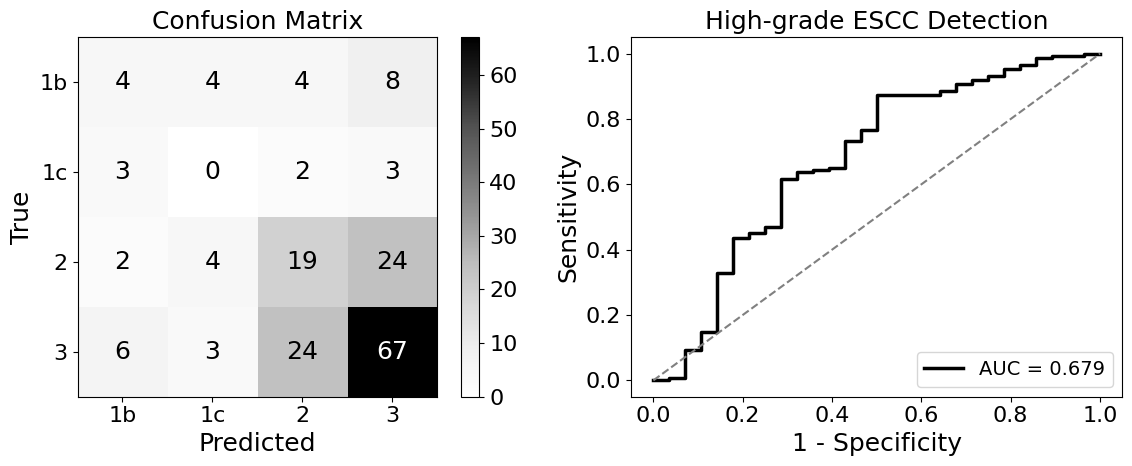


Saved figure: Figure_ESCC_177_bw.png


In [10]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Figure Generation: ESCC CNN Performance
[177-case version | black-and-white | CI calculated but not shown in figure]

Generates:
    - Confusion Matrix (4-class)
    - ROC curve (High-grade ESCC)
    - Macro AUC
    - Bootstrap 95% CIs for binary AUC and macro AUC (console output only)

Input:
    - escc_oof_predictions_177.csv
    - ESCC_3_with_consensus_177.xlsx

Output:
    - Figure_ESCC_177_bw.png
"""

# =============================================================================
# Imports
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample

# =============================================================================
# Configuration
# =============================================================================
PRED_FILE = "escc_oof_predictions_177.csv"
GT_FILE = "ESCC_3_with_consensus_177.xlsx"
OUTPUT_FIG = "Figure_ESCC_177_bw.png"

VALID_LABELS = ["1b", "1c", "2", "3"]
N_BOOT = 1000
RANDOM_STATE = 42

# =============================================================================
# Font
# =============================================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "axes.unicode_minus": False,
})

# =============================================================================
# Load data
# =============================================================================
pred = pd.read_csv(PRED_FILE)
gt = pd.read_excel(GT_FILE)

# =============================================================================
# Normalize filename
# =============================================================================
pred["filename_clean"] = (
    pred["filename"]
    .astype(str)
    .str.replace(r"\.[A-Za-z0-9]+$", "", regex=True)
    .str.lower()
)

gt["filename_clean"] = (
    gt["filename"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# =============================================================================
# Merge
# =============================================================================
df = pred.merge(
    gt[["filename_clean", "ESCC_consensus"]],
    on="filename_clean",
    how="inner"
)

print("Merged cases before filtering:", len(df))

df = df[df["ESCC_consensus"].isin(VALID_LABELS)].copy()
df = df[df["pred_label"].isin(VALID_LABELS)].copy()
df["true_label"] = df["ESCC_consensus"]

print("Merged cases after filtering:", len(df))

# =============================================================================
# Confusion Matrix
# =============================================================================
cm = confusion_matrix(df["true_label"], df["pred_label"], labels=VALID_LABELS)

# =============================================================================
# Binary ROC (High-grade ESCC = 2/3)
# =============================================================================
df["binary_true"] = df["true_label"].isin(["2", "3"]).astype(int)
df["binary_prob"] = df["prob_2"] + df["prob_3"]

fpr, tpr, _ = roc_curve(df["binary_true"], df["binary_prob"])
binary_auc = auc(fpr, tpr)

# Bootstrap CI for binary AUC
rng = np.random.RandomState(RANDOM_STATE)
binary_boot = []

for i in range(N_BOOT):
    sample = resample(df, replace=True, random_state=rng.randint(0, 10**9))

    if sample["binary_true"].nunique() < 2:
        continue

    fpr_b, tpr_b, _ = roc_curve(sample["binary_true"], sample["binary_prob"])
    binary_boot.append(auc(fpr_b, tpr_b))

binary_ci_l = np.percentile(binary_boot, 2.5)
binary_ci_u = np.percentile(binary_boot, 97.5)

# =============================================================================
# Macro AUC
# =============================================================================
y_true_bin = label_binarize(df["true_label"], classes=VALID_LABELS)
y_score = df[[f"prob_{lab}" for lab in VALID_LABELS]].values

macro_auc = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")

# Bootstrap CI for macro AUC
macro_boot = []

for i in range(N_BOOT):
    sample = resample(df, replace=True, random_state=rng.randint(0, 10**9))

    ys = label_binarize(sample["true_label"], classes=VALID_LABELS)
    ps = sample[[f"prob_{lab}" for lab in VALID_LABELS]].values

    try:
        val = roc_auc_score(ys, ps, average="macro", multi_class="ovr")
        macro_boot.append(val)
    except Exception:
        continue

macro_ci_l = np.percentile(macro_boot, 2.5)
macro_ci_u = np.percentile(macro_boot, 97.5)

# =============================================================================
# Print metrics for manuscript text
# =============================================================================
print("\n=== AUCs for Manuscript / Supplement ===")
print(f"Binary AUC (2/3 vs 1b/1c): {binary_auc:.3f} "
      f"(95% CI {binary_ci_l:.3f}–{binary_ci_u:.3f})")
print(f"Macro AUC (4-class): {macro_auc:.3f} "
      f"(95% CI {macro_ci_l:.3f}–{macro_ci_u:.3f})")

# =============================================================================
# Plot
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------
# Confusion Matrix
# -----------------------
im = axes[0].imshow(cm, cmap="Greys")

axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

axes[0].set_xticks(range(len(VALID_LABELS)))
axes[0].set_yticks(range(len(VALID_LABELS)))
axes[0].set_xticklabels(VALID_LABELS)
axes[0].set_yticklabels(VALID_LABELS)

for i in range(len(VALID_LABELS)):
    for j in range(len(VALID_LABELS)):
        color = "white" if cm[i, j] > cm.max() * 0.5 else "black"
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.colorbar(im, ax=axes[0])

# -----------------------
# ROC Curve
# -----------------------
axes[1].plot(
    fpr, tpr,
    color="black",
    linewidth=2.5,
    label=f"AUC = {binary_auc:.3f}"
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")

axes[1].set_title("High-grade ESCC Detection")
axes[1].set_xlabel("1 - Specificity")
axes[1].set_ylabel("Sensitivity")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=600, bbox_inches="tight")
plt.show()

print(f"\nSaved figure: {OUTPUT_FIG}")

In [11]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Unified Reproducible Analysis Script (Final 177-case version)
-------------------------------------------------------------
Multimodal Survival Prediction in Metastatic Spine Surgery

This script reproduces the main analyses:

    • 5-fold out-of-fold (OOF) LightGBM models
      with isotonic calibration for 3M / 6M / 12M survival

    • ROC curves and calibration plots (black-and-white final version)
    • SHAP summary plots
    • SHAP mean-absolute heatmap

    • Performance_Summary_OOF_177.xlsx
          - AUC, 95% CI, Sensitivity, Specificity, F1, Brier (LightGBM)
          - AUC, 95% CI, Sensitivity, Specificity, F1 (Tokuhashi, Katagiri)
          - DeLong-type p values for LightGBM vs Tokuhashi / Katagiri

    • Ablation_Study_Output_177.xlsx
          - Full model (clinical + ESCC) vs Clinical-only

    • Spearman_Correlation_177.xlsx
          - Spearman correlation between ESCC and ECOG / Barthel

Input:
    MRI_ALLdata_OOF177.xlsx

Outputs:
    ./RESULTS_FIGURES_177/
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import norm, spearmanr

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.isotonic import IsotonicRegression

# =============================================================================
# Global settings
# =============================================================================
OUT_DIR = Path("RESULTS_FIGURES_177")
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# =============================================================================
# Utilities
# =============================================================================
def map_sex(x):
    s = str(x).strip().lower()
    if s in ["1", "m", "male", "男", "男性"]:
        return 1
    if s in ["0", "f", "female", "女", "女性"]:
        return 0
    return np.nan


def map_escc(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace(" ", "")
    return {"1a": 1, "1b": 2, "1c": 3, "2": 4, "3": 5}.get(s, np.nan)


def frankel_bin(x):
    s = str(x).strip().upper()
    if s in ["A", "B", "C"]:
        return 0
    if s in ["D", "E"]:
        return 1
    return np.nan


def map_yesno(x):
    s = str(x).strip().lower()
    if s in ["yes", "y", "true", "1", "あり", "有"]:
        return 1
    if s in ["no", "n", "false", "0", "なし", "無"]:
        return 0
    return np.nan


def auc_ci_bootstrap(y, p, n_boot=2000, seed=42):
    y = np.asarray(y)
    p = np.asarray(p)
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    aucs = []

    for _ in range(n_boot):
        b = rng.choice(idx, len(idx), replace=True)
        try:
            aucs.append(roc_auc_score(y[b], p[b]))
        except ValueError:
            pass

    auc = roc_auc_score(y, p)
    lo, hi = np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)
    return auc, lo, hi


def delong_type_test(y, p1, p2):
    """
    DeLong-type paired ROC comparison.
    This is a simplified paired comparison, not the full canonical DeLong covariance estimator.
    Returns:
        delta_auc, p_value
    """
    y = np.asarray(y)
    p1 = np.asarray(p1)
    p2 = np.asarray(p2)

    m = int(np.sum(y))
    n = len(y) - m

    if m == 0 or n == 0:
        return np.nan, np.nan

    a1 = roc_auc_score(y, p1)
    a2 = roc_auc_score(y, p2)

    var = (a1 * (1 - a1) / max(n, 1)) + (a2 * (1 - a2) / max(n, 1))
    z = (a1 - a2) / np.sqrt(var + 1e-12)
    p = 2 * (1 - norm.cdf(abs(z)))
    return a1 - a2, p


def get_binary_metrics(y, p, thr=0.5):
    y = np.asarray(y)
    p = np.asarray(p)
    yhat = (p >= thr).astype(int)

    cm = confusion_matrix(y, yhat, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    _, _, f1, _ = precision_recall_fscore_support(
        y, yhat, average="binary", zero_division=0
    )
    return sens, spec, f1


def youden_threshold(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    return thr[np.argmax(tpr - fpr)]


# =============================================================================
# OOF LightGBM + isotonic calibration
# =============================================================================
def run_lgb_oof_calibrated(X, y):
    """
    Train LightGBM using OOF predictions and isotonic calibration.
    Returns:
        calibrated_oof_predictions, final_model
    """
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    params = dict(
        objective="binary",
        metric="auc",
        learning_rate=0.05,
        num_leaves=31,
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
    )

    oof = np.zeros(len(y))

    for tr, te in skf.split(X, y):
        model = lgb.LGBMClassifier(**params)
        model.fit(X.iloc[tr], y[tr])
        oof[te] = model.predict_proba(X.iloc[te])[:, 1]

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(oof, y)
    calibrated = iso.transform(oof)

    final_model = lgb.LGBMClassifier(**params)
    final_model.fit(X, y)

    return calibrated, final_model


# =============================================================================
# Plotting
# =============================================================================
def plot_roc(ax, y, p_lgb, p_tok, p_kat, title):
    fpr_lgb, tpr_lgb, _ = roc_curve(y, p_lgb)
    fpr_tok, tpr_tok, _ = roc_curve(y, p_tok)
    fpr_kat, tpr_kat, _ = roc_curve(y, p_kat)

    ax.plot(
        fpr_lgb, tpr_lgb,
        color="black", lw=2.5,
        label=f"LightGBM model (AUC={roc_auc_score(y, p_lgb):.3f})"
    )
    ax.plot(
        fpr_tok, tpr_tok,
        color="black", ls="--", lw=2.0,
        label=f"Revised Tokuhashi (AUC={roc_auc_score(y, p_tok):.3f})"
    )
    ax.plot(
        fpr_kat, tpr_kat,
        color="black", ls=":", lw=2.0,
        label=f"New Katagiri (AUC={roc_auc_score(y, p_kat):.3f})"
    )

    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("1 - Specificity", fontsize=18)
    ax.set_ylabel("Sensitivity", fontsize=18)
    ax.tick_params(labelsize=16)
    ax.legend(loc="lower right", fontsize=12)


def plot_calibration(ax, y, p):
    d = pd.DataFrame({"y": y, "p": p})
    d["bin"] = pd.qcut(d["p"], q=10, duplicates="drop")
    g = d.groupby("bin", observed=False).agg(
        obs=("y", "mean"),
        pred=("p", "mean")
    ).reset_index()

    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
    ax.plot(g["pred"], g["obs"], "o-", color="black", lw=2)

    ax.set_title("Calibration plot", fontsize=18)
    ax.set_xlabel("Predicted probability", fontsize=18)
    ax.set_ylabel("Observed frequency", fontsize=18)
    ax.tick_params(labelsize=16)


def shap_summary_plot(model, X, title, filename, rename_map=None):
    X_disp = X.copy()
    if rename_map is not None:
        X_disp = X_disp.rename(columns=rename_map)

    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X)

    if isinstance(sv, list):
        sv = sv[1]

    shap.summary_plot(sv, X_disp, show=False)

    fig = plt.gcf()
    ax = plt.gca()

    ax.tick_params(axis="x", labelsize=12)
    for t in ax.get_yticklabels():
        t.set_fontsize(12)

    try:
        cbar = fig.axes[-1]
        cbar.tick_params(labelsize=12)
        cbar.set_ylabel(cbar.get_ylabel(), fontsize=12)
    except Exception:
        pass

    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=600, bbox_inches="tight")
    plt.close()


def shap_mean_heatmap(models, X_dict, features, filename, rename_map=None):
    display_features = [rename_map.get(f, f) if rename_map else f for f in features]
    table = pd.DataFrame(index=display_features, columns=models.keys())

    for tag, model in models.items():
        X = X_dict[tag]
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X)

        if isinstance(sv, list):
            sv = sv[1]

        abs_mean = np.abs(sv).mean(axis=0)
        for f_orig, f_disp, val in zip(features, display_features, abs_mean):
            table.loc[f_disp, tag] = val

    if "3M" in models:
        table = table.sort_values(by="3M", ascending=False)

    plt.figure(figsize=(8, 7))
    ax = plt.gca()
    im = ax.imshow(table.astype(float).values, cmap="Greys", aspect="auto")

    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns, fontsize=12)
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index, fontsize=12)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            val = float(table.iloc[i, j])
            color = "white" if val > np.nanmax(table.astype(float).values) * 0.5 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=color, fontsize=11)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("mean(|SHAP value|)", fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    ax.set_title("SHAP Heatmap", fontsize=16)
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=600, bbox_inches="tight")
    plt.close()


# =============================================================================
# Load data
# =============================================================================
INPUT_XLSX = "MRI_ALLdata_OOF177.xlsx"
df_raw = pd.read_excel(INPUT_XLSX)
df_raw.columns = df_raw.columns.str.strip()

df = pd.DataFrame({
    "Age": pd.to_numeric(df_raw["Age"], errors="coerce"),
    "Sex": df_raw["Sex"].apply(map_sex),
    "Number of spinal metastases": pd.to_numeric(df_raw["Number of Spinal Metastases"], errors="coerce"),
    "Albumin": pd.to_numeric(df_raw["Serum Albumin"], errors="coerce"),
    "CRP": pd.to_numeric(df_raw["CRP"], errors="coerce"),
    "ESCC": df_raw["ESCC"].apply(map_escc),
    "ECOG": pd.to_numeric(df_raw["Performance Status (ECOG)"], errors="coerce"),
    "Frankel grade": df_raw["Frankel Grade"].apply(frankel_bin),
    "Barthel Index": pd.to_numeric(df_raw["Barthel Index (ADL)"], errors="coerce"),
    "Malignancy (New Katagiri score)": pd.to_numeric(df_raw["Malignancy (Katagiri Score)"], errors="coerce"),
    "Visceral metastasis": df_raw["Visceral Metastasis (Yes=1/No=0)"].apply(map_yesno),
    "BMI": pd.to_numeric(df_raw["Body Mass Index (BMI)"], errors="coerce"),

    # Classical prognostic systems
    "Tokuhashi_binary": (pd.to_numeric(df_raw["Revised Tokuhashi score"], errors="coerce") >= 9).astype(float),
    "Katagiri_binary": (pd.to_numeric(df_raw["New Katagiri score"], errors="coerce") < 7).astype(float),

    # Outcomes
    "Y_3M": pd.to_numeric(df_raw["3-Month Survival (0=Death, 1=Alive)"], errors="coerce"),
    "Y_6M": pd.to_numeric(df_raw["6-Month Survival (0=Death, 1=Alive)"], errors="coerce"),
    "Y_12M": pd.to_numeric(df_raw["12-Month Survival (0=Death, 1=Alive)"], errors="coerce"),
})

# =============================================================================
# Feature definitions
# =============================================================================
FEATURES = [
    "CRP",
    "Malignancy (New Katagiri score)",
    "Age",
    "Barthel Index",
    "Albumin",
    "BMI",
    "ESCC",
    "ECOG",
    "Number of spinal metastases",
    "Sex",
    "Frankel grade",
    "Visceral metastasis",
]

FEATURE_RENAME = {
    "CRP": "CRP",
    "Malignancy (New Katagiri score)": "Malignancy (New Katagiri score)",
    "Age": "Age",
    "Barthel Index": "Barthel Index",
    "Albumin": "Albumin",
    "BMI": "BMI",
    "ESCC": "ESCC grade",
    "ECOG": "ECOG performance status",
    "Number of spinal metastases": "Number of spinal metastases",
    "Sex": "Sex",
    "Frankel grade": "Frankel grade",
    "Visceral metastasis": "Visceral metastasis",
}

FEATURES_NO_ESCC = [f for f in FEATURES if f != "ESCC"]

# =============================================================================
# 1. Spearman correlation
# =============================================================================
corr_sub = df.dropna(subset=["ESCC", "ECOG", "Barthel Index"]).copy()

rho_ecog, p_ecog = spearmanr(corr_sub["ESCC"], corr_sub["ECOG"])
rho_barthel, p_barthel = spearmanr(corr_sub["ESCC"], corr_sub["Barthel Index"])

corr_df = pd.DataFrame([
    {"Variable_1": "ESCC", "Variable_2": "ECOG", "Spearman_rho": rho_ecog, "p_value": p_ecog, "n": len(corr_sub)},
    {"Variable_1": "ESCC", "Variable_2": "Barthel Index", "Spearman_rho": rho_barthel, "p_value": p_barthel, "n": len(corr_sub)},
])

corr_df.to_excel(OUT_DIR / "Spearman_Correlation_177.xlsx", index=False)

print("\n=== Spearman correlation ===")
print(corr_df)

# =============================================================================
# 2. Main survival analysis
# =============================================================================
perf_records = []
models_by_horizon = {}
X_dict = {}

for tag, ycol in [("3M", "Y_3M"), ("6M", "Y_6M"), ("12M", "Y_12M")]:
    sub = df.dropna(subset=FEATURES + [ycol]).copy()
    X = sub[FEATURES]
    y = sub[ycol].astype(int).values

    X_dict[tag] = X

    # LightGBM OOF calibrated model
    p_lgb, model_lgb = run_lgb_oof_calibrated(X, y)
    models_by_horizon[tag] = model_lgb

    # Classical scores
    p_tok = sub["Tokuhashi_binary"].astype(float).values
    p_kat = sub["Katagiri_binary"].astype(float).values

    # Figures
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    plot_roc(axes[0], y, p_lgb, p_tok, p_kat, f"{tag} survival")
    plot_calibration(axes[1], y, p_lgb)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"Figure3_{tag}_bw.png", dpi=600, bbox_inches="tight")
    plt.close()

    # SHAP summary
    shap_summary_plot(
        model_lgb, X,
        f"SHAP summary ({tag})",
        f"SHAP_{tag}_177.png",
        rename_map=FEATURE_RENAME
    )

    # Metrics with bootstrap CI
    lgb_auc, lgb_lo, lgb_hi = auc_ci_bootstrap(y, p_lgb)
    tok_auc, tok_lo, tok_hi = auc_ci_bootstrap(y, p_tok)
    kat_auc, kat_lo, kat_hi = auc_ci_bootstrap(y, p_kat)

    # DeLong-type tests
    delta_tok, p_lgb_vs_tok = delong_type_test(y, p_lgb, p_tok)
    delta_kat, p_lgb_vs_kat = delong_type_test(y, p_lgb, p_kat)

    # Threshold-based metrics
    thr_lgb = youden_threshold(y, p_lgb)
    sens_lgb, spec_lgb, f1_lgb = get_binary_metrics(y, p_lgb, thr_lgb)
    sens_tok, spec_tok, f1_tok = get_binary_metrics(y, p_tok, 0.5)
    sens_kat, spec_kat, f1_kat = get_binary_metrics(y, p_kat, 0.5)

    brier_lgb = brier_score_loss(y, p_lgb)

    perf_records.append({
        "Horizon": tag,
        "n": len(sub),

        "LightGBM AUC": lgb_auc,
        "LightGBM 95% CI low": lgb_lo,
        "LightGBM 95% CI high": lgb_hi,
        "LightGBM Sensitivity": sens_lgb,
        "LightGBM Specificity": spec_lgb,
        "LightGBM F1": f1_lgb,
        "LightGBM Brier": brier_lgb,

        "Tokuhashi AUC": tok_auc,
        "Tokuhashi 95% CI low": tok_lo,
        "Tokuhashi 95% CI high": tok_hi,
        "Tokuhashi Sensitivity": sens_tok,
        "Tokuhashi Specificity": spec_tok,
        "Tokuhashi F1": f1_tok,

        "Katagiri AUC": kat_auc,
        "Katagiri 95% CI low": kat_lo,
        "Katagiri 95% CI high": kat_hi,
        "Katagiri Sensitivity": sens_kat,
        "Katagiri Specificity": spec_kat,
        "Katagiri F1": f1_kat,

        "Delta AUC (LightGBM - Tokuhashi)": delta_tok,
        "p (LightGBM vs Tokuhashi)": p_lgb_vs_tok,
        "Delta AUC (LightGBM - Katagiri)": delta_kat,
        "p (LightGBM vs Katagiri)": p_lgb_vs_kat,
    })

perf_df = pd.DataFrame(perf_records)
perf_df.to_excel(OUT_DIR / "Performance_Summary_OOF_177.xlsx", index=False)

print("\n=== Performance summary ===")
print(perf_df)

# =============================================================================
# 3. SHAP mean heatmap
# =============================================================================
shap_mean_heatmap(
    models_by_horizon,
    X_dict,
    FEATURES,
    "SHAP_heatmap_3M_6M_12M_177_bw.png",
    rename_map=FEATURE_RENAME,
)

# =============================================================================
# 4. Ablation study
# =============================================================================
ablation_records = []

for tag, ycol in [("3M", "Y_3M"), ("6M", "Y_6M"), ("12M", "Y_12M")]:
    sub = df.dropna(subset=FEATURES + [ycol]).copy()

    X_full = sub[FEATURES]
    X_no = sub[FEATURES_NO_ESCC]
    y = sub[ycol].astype(int).values

    p_full, _ = run_lgb_oof_calibrated(X_full, y)
    p_no, _ = run_lgb_oof_calibrated(X_no, y)

    auc_full = roc_auc_score(y, p_full)
    auc_no = roc_auc_score(y, p_no)

    brier_full = brier_score_loss(y, p_full)
    brier_no = brier_score_loss(y, p_no)

    sens_full, spec_full, f1_full = get_binary_metrics(y, p_full, 0.5)
    sens_no, spec_no, f1_no = get_binary_metrics(y, p_no, 0.5)

    delta_auc, p_delong = delong_type_test(y, p_full, p_no)

    ablation_records.append({
        "Horizon": tag,
        "n": len(sub),
        "AUC_Full (clinical + ESCC)": auc_full,
        "AUC_No_ESCC (clinical only)": auc_no,
        "Delta AUC (Full - No_ESCC)": delta_auc,
        "p (DeLong-type)": p_delong,
        "Brier_Full": brier_full,
        "Brier_No_ESCC": brier_no,
        "Sensitivity_Full": sens_full,
        "Specificity_Full": spec_full,
        "F1_Full": f1_full,
        "Sensitivity_No_ESCC": sens_no,
        "Specificity_No_ESCC": spec_no,
        "F1_No_ESCC": f1_no,
    })

ablation_df = pd.DataFrame(ablation_records)
ablation_df.to_excel(OUT_DIR / "Ablation_Study_Output_177.xlsx", index=False)

print("\n=== Ablation study ===")
print(ablation_df)

print("\nAnalysis completed successfully.")
print("Results saved in:", OUT_DIR.resolve())


=== Spearman correlation ===
  Variable_1     Variable_2  Spearman_rho   p_value    n
0       ESCC           ECOG      0.040268  0.594625  177
1       ESCC  Barthel Index     -0.112954  0.134418  177
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 109, number of negative: 31
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 183
[LightGBM] [Info] Number of data points in the train set: 140, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_3156/2013073090.py:270: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_disp, show=False)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 83, number of negative: 57
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 181
[LightGBM] [Info] Number of data points in the train set: 140, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_3156/2013073090.py:270: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_disp, show=False)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 62, number of negative: 78
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000028 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 179
[LightGBM] [Info] Number of data points in the train set: 140, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_3156/2013073090.py:270: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_disp, show=False)



=== Performance summary ===
  Horizon    n  LightGBM AUC  LightGBM 95% CI low  LightGBM 95% CI high  \
0      3M  175      0.730215             0.646965              0.807168   
1      6M  175      0.832746             0.774613              0.885208   
2     12M  175      0.866618             0.813697              0.914824   

   LightGBM Sensitivity  LightGBM Specificity  LightGBM F1  LightGBM Brier  \
0              0.649635              0.710526     0.751055        0.150051   
1              0.634615              0.873239     0.737430        0.160503   
2              0.597403              0.918367     0.702290        0.140864   

   Tokuhashi AUC  ...  Katagiri AUC  Katagiri 95% CI low  \
0       0.606512  ...      0.666827             0.581246   
1       0.659331  ...      0.693256             0.621081   
2       0.698052  ...      0.702226             0.643468   

   Katagiri 95% CI high  Katagiri Sensitivity  Katagiri Specificity  \
0              0.753139              0.781022

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


ストリーミング出力は最後の 5000 行に切り捨てられました。
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [12]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Supplementary Analysis:
Spearman Correlation and Integrated Partial Dependence Plot (PDP)
----------------------------------------------------------------

This script computes:

1. Spearman correlation between ESCC severity and
   clinical functional markers (ECOG and Barthel Index)
   for each survival horizon (3M, 6M, 12M).

2. Integrated partial dependence plot (PDP) for ESCC
   using trained LightGBM models.

Required variables from code5:
    - models_by_horizon
    - X_dict
    - OUT_DIR

Outputs:
    - Supplementary_ESCC_Spearman.xlsx
    - Supplementary_ESCC_PDP_all_bw.png
"""

from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def compute_spearman_and_plot_pdp(models_by_horizon, X_dict, out_dir):
    """
    Compute Spearman correlations and generate integrated PDP plot.

    Parameters
    ----------
    models_by_horizon : dict
        Dictionary of trained LightGBM models for {"3M", "6M", "12M"}.
    X_dict : dict
        Dictionary of predictor matrices for each horizon.
    out_dir : pathlib.Path
        Output directory.
    """

    # ============================================================
    # 1. Spearman Correlation Summary
    # ============================================================
    spearman_records = []

    for tag in ["3M", "6M", "12M"]:
        X = X_dict[tag].copy()

        rho_ecog, p_ecog = spearmanr(X["ESCC"], X["ECOG"], nan_policy="omit")
        rho_barthel, p_barthel = spearmanr(X["ESCC"], X["Barthel Index"], nan_policy="omit")

        spearman_records.append({
            "Horizon": tag,
            "Spearman_ESCC_ECOG": rho_ecog,
            "p_value_ECOG": p_ecog,
            "Spearman_ESCC_Barthel": rho_barthel,
            "p_value_Barthel": p_barthel,
            "n": len(X),
        })

        print(f"\n=== Spearman ({tag}) ===")
        print(f"  ESCC vs ECOG    : rho={rho_ecog:.3f}, p={p_ecog:.4f}")
        print(f"  ESCC vs Barthel : rho={rho_barthel:.3f}, p={p_barthel:.4f}")

    spearman_df = pd.DataFrame(spearman_records)
    spearman_path = out_dir / "Supplementary_ESCC_Spearman.xlsx"
    spearman_df.to_excel(spearman_path, index=False)
    print(f"\nSaved Spearman correlation summary -> {spearman_path}")

    # ============================================================
    # 2. Integrated Partial Dependence Plot (PDP)
    # ============================================================
    escc_levels = sorted(X_dict["3M"]["ESCC"].dropna().unique())  # e.g. [2, 3, 4, 5]
    pdp = {}

    for tag in ["3M", "6M", "12M"]:
        model = models_by_horizon[tag]
        X_base = X_dict[tag].copy()

        vals = []
        for g in escc_levels:
            X_temp = X_base.copy()
            X_temp["ESCC"] = g
            prob_alive = model.predict_proba(X_temp)[:, 1]
            prob_death = 1 - prob_alive
            vals.append(np.mean(prob_death))

        pdp[tag] = np.array(vals)

    # Map ESCC numeric codes to Bilsky labels
    label_map = {2: "1b", 3: "1c", 4: "2", 5: "3"}
    tick_labels = [label_map.get(x, str(x)) for x in escc_levels]

    # ============================================================
    # 3. Plot Integrated PDP (black-and-white final version)
    # ============================================================
    plt.figure(figsize=(8, 6))

    plt.plot(
        escc_levels, pdp["3M"],
        color="black", lw=2.8, linestyle="-", marker="o",
        label="3M survival",
    )

    plt.plot(
        escc_levels, pdp["6M"],
        color="black", lw=2.4, linestyle="--", marker="o",
        label="6M survival",
    )

    plt.plot(
        escc_levels, pdp["12M"],
        color="black", lw=2.4, linestyle=":", marker="o",
        label="12M survival",
    )

    plt.title("Partial dependence of ESCC on predicted mortality risk", fontsize=18)
    plt.xlabel("ESCC grade", fontsize=16)
    plt.ylabel("Mean predicted mortality risk", fontsize=16)

    plt.xticks(escc_levels, tick_labels, fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(
        fontsize=12,
        frameon=True,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderpad=0.8
    )

    plt.tight_layout()
    out_path = out_dir / "Supplementary_ESCC_PDP_all_bw.png"
    plt.savefig(out_path, dpi=600, bbox_inches="tight")
    plt.close()

    print(f"\nIntegrated PDP figure saved -> {out_path}")


# Execute
compute_spearman_and_plot_pdp(models_by_horizon, X_dict, OUT_DIR)


=== Spearman (3M) ===
  ESCC vs ECOG    : rho=0.030, p=0.6972
  ESCC vs Barthel : rho=-0.103, p=0.1752

=== Spearman (6M) ===
  ESCC vs ECOG    : rho=0.030, p=0.6972
  ESCC vs Barthel : rho=-0.103, p=0.1752

=== Spearman (12M) ===
  ESCC vs ECOG    : rho=0.030, p=0.6972
  ESCC vs Barthel : rho=-0.103, p=0.1752

Saved Spearman correlation summary -> RESULTS_FIGURES_177/Supplementary_ESCC_Spearman.xlsx

Integrated PDP figure saved -> RESULTS_FIGURES_177/Supplementary_ESCC_PDP_all_bw.png


In [13]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Final Table3 / Table4 unified analysis
--------------------------------------

This script generates:

1. Table3_ablation_177_final.xlsx
   - Full model (clinical + CNN-derived ESCC) vs Clinical-only
   - AUC, 95% CI, Brier
   - Delta AUC / Delta Brier
   - DeLong-type p value

2. Table4_expert_vs_cnn_177_final.xlsx
   - Clinical-only vs Clinical + Expert ESCC vs Clinical + CNN-derived ESCC
   - AUC, 95% CI, Brier
   - Delta AUC / Delta Brier (CNN vs Expert)
   - DeLong-type p value (CNN vs Expert)

Input:
    MRI_ALLdata_OOF177.xlsx
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import pandas as pd
import lightgbm as lgb

from scipy.stats import norm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.isotonic import IsotonicRegression


# =============================================================================
# Load data
# =============================================================================
INPUT_FILE = "MRI_ALLdata_OOF177.xlsx"

df = pd.read_excel(INPUT_FILE)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")].copy()
df.columns = df.columns.str.strip()


# =============================================================================
# Utility mappings
# =============================================================================
def map_escc_any(x):
    """
    ESCC mapping:
        1a -> 1
        1b -> 2
        1c -> 3
        2  -> 4
        3  -> 5
    """
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().lower().replace(" ", "")
    return {"1a": 1, "1b": 2, "1c": 3, "2": 4, "3": 5}.get(s, np.nan)


def frankel_to_binary(x):
    s = str(x).strip().upper()
    if s in ["A", "B", "C"]:
        return 0
    if s in ["D", "E"]:
        return 1
    return np.nan


def map_sex_any(x):
    s = str(x).strip().lower()
    if s in ["1", "m", "male", "男", "男性"]:
        return 1
    if s in ["0", "f", "female", "女", "女性"]:
        return 0
    return np.nan


def map_yesno_any(x):
    s = str(x).strip().lower()
    if s in ["1", "yes", "y", "true", "あり", "有"]:
        return 1
    if s in ["0", "no", "n", "false", "なし", "無"]:
        return 0
    return np.nan


# =============================================================================
# Column preparation
# =============================================================================
# ESCC columns
df["ESCC_cnn"] = df["ESCC"].apply(map_escc_any)

if "Expert" in df.columns:
    df["ESCC_expert"] = df["Expert"].apply(map_escc_any)
else:
    raise ValueError("Column 'Expert' not found in MRI_ALLdata_OOF177.xlsx")

# Frankel
df["Frankel Grade"] = df["Frankel Grade"].apply(frankel_to_binary)

# Sex / visceral robust conversion if needed
if "Sex" in df.columns:
    df["Sex"] = df["Sex"].apply(map_sex_any)

if "Visceral Metastasis (Yes=1/No=0)" in df.columns:
    df["Visceral Metastasis (Yes=1/No=0)"] = df["Visceral Metastasis (Yes=1/No=0)"].apply(map_yesno_any)

# Force numeric conversion
NUMERIC_COLUMNS = [
    "CRP",
    "Malignancy (Katagiri Score)",
    "Age",
    "Barthel Index (ADL)",
    "Serum Albumin",
    "Body Mass Index (BMI)",
    "Performance Status (ECOG)",
    "Number of Spinal Metastases",
    "Sex",
    "Frankel Grade",
    "Visceral Metastasis (Yes=1/No=0)",
    "ESCC_cnn",
    "ESCC_expert",
    "3-Month Survival (0=Death, 1=Alive)",
    "6-Month Survival (0=Death, 1=Alive)",
    "12-Month Survival (0=Death, 1=Alive)",
]

for col in NUMERIC_COLUMNS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# =============================================================================
# Feature definitions
# =============================================================================
BASE_FEATURES = [
    "CRP",
    "Malignancy (Katagiri Score)",
    "Age",
    "Barthel Index (ADL)",
    "Serum Albumin",
    "Body Mass Index (BMI)",
    "Performance Status (ECOG)",
    "Number of Spinal Metastases",
    "Sex",
    "Frankel Grade",
    "Visceral Metastasis (Yes=1/No=0)",
]

FEATURES_FULL = BASE_FEATURES + ["ESCC_cnn"]
FEATURES_NO_ESCC = BASE_FEATURES

FEATURES_CLINICAL = BASE_FEATURES
FEATURES_EXPERT = BASE_FEATURES + ["ESCC_expert"]
FEATURES_CNN = BASE_FEATURES + ["ESCC_cnn"]


# =============================================================================
# Core statistics
# =============================================================================
def auc_ci_bootstrap(y, p, n_boot=2000, seed=42):
    y = np.asarray(y)
    p = np.asarray(p)

    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    aucs = []

    for _ in range(n_boot):
        b = rng.choice(idx, len(idx), replace=True)
        try:
            aucs.append(roc_auc_score(y[b], p[b]))
        except ValueError:
            pass

    auc = roc_auc_score(y, p)
    lo, hi = np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)
    return auc, lo, hi


def delong_type_test(y, p1, p2):
    """
    Simplified paired ROC comparison.
    Returns:
        delta_auc, p_value
    """
    y = np.asarray(y)
    p1 = np.asarray(p1)
    p2 = np.asarray(p2)

    m = int(np.sum(y))
    n = len(y) - m

    if m == 0 or n == 0:
        return np.nan, np.nan

    a1 = roc_auc_score(y, p1)
    a2 = roc_auc_score(y, p2)

    var = (a1 * (1 - a1) / max(n, 1)) + (a2 * (1 - a2) / max(n, 1))
    z = (a1 - a2) / np.sqrt(var + 1e-12)
    p = 2 * (1 - norm.cdf(abs(z)))
    return a1 - a2, p


def run_lgb_oof_calibrated(X, y, n_splits=5):
    """
    Leakage-free OOF LightGBM with isotonic calibration.
    Returns calibrated OOF predictions.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    params = dict(
        objective="binary",
        metric="auc",
        learning_rate=0.05,
        num_leaves=31,
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
    )

    oof_pred = np.zeros(len(y))

    for tr_idx, te_idx in skf.split(X, y):
        model = lgb.LGBMClassifier(**params)
        model.fit(X.iloc[tr_idx], y[tr_idx])
        oof_pred[te_idx] = model.predict_proba(X.iloc[te_idx])[:, 1]

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(oof_pred, y)
    p_cal = iso.transform(oof_pred)

    return p_cal


# =============================================================================
# Table 3: Ablation study
# =============================================================================
table3_records = []

for tag, ycol in [
    ("3M", "3-Month Survival (0=Death, 1=Alive)"),
    ("6M", "6-Month Survival (0=Death, 1=Alive)"),
    ("12M", "12-Month Survival (0=Death, 1=Alive)")
]:
    sub = df.dropna(subset=FEATURES_FULL + [ycol]).copy()
    y = sub[ycol].astype(int).values

    p_full = run_lgb_oof_calibrated(sub[FEATURES_FULL], y)
    p_no = run_lgb_oof_calibrated(sub[FEATURES_NO_ESCC], y)

    auc_full, auc_full_lo, auc_full_hi = auc_ci_bootstrap(y, p_full)
    auc_no, auc_no_lo, auc_no_hi = auc_ci_bootstrap(y, p_no)

    brier_full = brier_score_loss(y, p_full)
    brier_no = brier_score_loss(y, p_no)

    delta_auc, p_delong = delong_type_test(y, p_full, p_no)

    table3_records.append({
        "Horizon": tag,
        "n": len(sub),

        "AUC_Full": auc_full,
        "AUC_Full_95CI_low": auc_full_lo,
        "AUC_Full_95CI_high": auc_full_hi,

        "AUC_No_ESCC": auc_no,
        "AUC_No_ESCC_95CI_low": auc_no_lo,
        "AUC_No_ESCC_95CI_high": auc_no_hi,

        "Delta_AUC": auc_full - auc_no,
        "p_DeLong_type": p_delong,

        "Brier_Full": brier_full,
        "Brier_No_ESCC": brier_no,
        "Delta_Brier": brier_full - brier_no,
    })

table3_df = pd.DataFrame(table3_records)
print("\n=== Table 3: Ablation ===")
print(table3_df)

table3_df.to_excel("Table3_ablation_177_final.xlsx", index=False)
print("Saved: Table3_ablation_177_final.xlsx")


# =============================================================================
# Table 4: Clinical vs Expert vs CNN
# =============================================================================
table4_records = []

for tag, ycol in [
    ("3M", "3-Month Survival (0=Death, 1=Alive)"),
    ("6M", "6-Month Survival (0=Death, 1=Alive)"),
    ("12M", "12-Month Survival (0=Death, 1=Alive)")
]:
    sub = df.dropna(subset=FEATURES_CLINICAL + ["ESCC_expert", "ESCC_cnn", ycol]).copy()
    y = sub[ycol].astype(int).values

    p_clin = run_lgb_oof_calibrated(sub[FEATURES_CLINICAL], y)
    p_exp = run_lgb_oof_calibrated(sub[FEATURES_EXPERT], y)
    p_cnn = run_lgb_oof_calibrated(sub[FEATURES_CNN], y)

    auc_clin, auc_clin_lo, auc_clin_hi = auc_ci_bootstrap(y, p_clin)
    auc_exp, auc_exp_lo, auc_exp_hi = auc_ci_bootstrap(y, p_exp)
    auc_cnn, auc_cnn_lo, auc_cnn_hi = auc_ci_bootstrap(y, p_cnn)

    brier_clin = brier_score_loss(y, p_clin)
    brier_exp = brier_score_loss(y, p_exp)
    brier_cnn = brier_score_loss(y, p_cnn)

    delta_auc_cnn_exp, p_cnn_vs_exp = delong_type_test(y, p_cnn, p_exp)

    table4_records.append({
        "Horizon": tag,
        "n": len(sub),

        "AUC_Clinical": auc_clin,
        "AUC_Clinical_95CI_low": auc_clin_lo,
        "AUC_Clinical_95CI_high": auc_clin_hi,

        "AUC_Expert": auc_exp,
        "AUC_Expert_95CI_low": auc_exp_lo,
        "AUC_Expert_95CI_high": auc_exp_hi,

        "AUC_CNN": auc_cnn,
        "AUC_CNN_95CI_low": auc_cnn_lo,
        "AUC_CNN_95CI_high": auc_cnn_hi,

        "Brier_Clinical": brier_clin,
        "Brier_Expert": brier_exp,
        "Brier_CNN": brier_cnn,

        "Delta_AUC_CNN_minus_Expert": auc_cnn - auc_exp,
        "Delta_Brier_CNN_minus_Expert": brier_cnn - brier_exp,
        "p_DeLong_type_CNN_vs_Expert": p_cnn_vs_exp,
    })

table4_df = pd.DataFrame(table4_records)
print("\n=== Table 4: Expert vs CNN ===")
print(table4_df)

table4_df.to_excel("Table4_expert_vs_cnn_177_final.xlsx", index=False)
print("Saved: Table4_expert_vs_cnn_177_final.xlsx")


print("\nAll analyses completed successfully.")

ストリーミング出力は最後の 5000 行に切り捨てられました。
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain